# Analysis of Player Deaths in World of Warcraft Classic Hardcore

# Introduction to the data
In this section we can see the structure of [Deathlog](https://github.com/aaronma37/Deathlog) database data

The data is stored in a JSON file named `deathlog.json`. Each entry in the JSON file represents a player death event, with various attributes such as `map_id`, `class_id`, `area_id`, `source_id`, `level`, and `instance_id`.
For better interpretation of the data I will now list the mapping from IDs to their respective meanings:

In [1]:
import pandas as pd
import json

# Load data from JSON file
with open('deathlog.json', 'r') as file:
    data = json.load(file)

df = pd.DataFrame.from_dict(data, orient='index')

print(df.head())
print(df.info())

                           map_id                                   map_pos  \
StoganHC Savages281022     1437.0                            [354.2, 518.1]   
PunkiieHC Waifus10448      1429.0   [265.40000000000003, 908.5999999999999]   
KittleHC Taco Stand152069  1439.0  [452.90000000000003, 248.79999999999998]   
KoycoreThe HC Gang71996    1438.0                [637.5999999999999, 689.8]   
ShpeilHC Care Bears121177  1432.0                            [361.3, 269.3]   

                           class_id  area_id  source_id  level  instance_id  
StoganHC Savages281022            1     1437       1022     28          NaN  
PunkiieHC Waifus10448             1     1429        448     10          NaN  
KittleHC Taco Stand152069         4     1439       2069     15          NaN  
KoycoreThe HC Gang71996           1     1438       1996      7          NaN  
ShpeilHC Care Bears121177         9     1432       1177     12          NaN  
<class 'pandas.core.frame.DataFrame'>
Index: 96603 entrie

## Mapping of IDs to Names
I think that it is worth mentioning that to obtain the mappings I had to go through the [Deathlog source code](https://github.com/aaronma37/Deathlog) and find it manually, since the mappings were not provided in the dataset itself.

### Class IDs to Class Names

In [2]:
class_id_to_class_name = {
    1: 'Warrior',
    2: 'Paladin',
    3: 'Hunter',
    4: 'Rogue',
    5: 'Priest',
    7: 'Shaman',
    8: 'Mage',
    9: 'Warlock',
    11: 'Druid'
}

### Map IDs to Map Names

In [3]:
map_id_to_map_name = {
    947: "Azeroth",
    1411: "Durotar",
    1412: "Mulgore",
    1413: "The Barrens",
    1414: "Kalimdor",
    1415: "Eastern Kingdoms",
    1416: "Alterac Mountains",
    1417: "Arathi Highlands",
    1418: "Badlands",
    1419: "Blasted Lands",
    1420: "Tirisfal Glades",
    1421: "Silverpine Forest",
    1422: "Western Plaguelands",
    1423: "Eastern Plaguelands",
    1424: "Hillsbrad Foothills",
    1425: "The Hinterlands",
    1426: "Dun Morogh",
    1427: "Searing Gorge",
    1428: "Burning Steppes",
    1429: "Elwynn Forest",
    1430: "Deadwind Pass",
    1431: "Duskwood",
    1432: "Loch Modan",
    1433: "Redridge Mountains",
    1434: "Stranglethorn Vale",
    1435: "Swamp of Sorrows",
    1436: "Westfall",
    1437: "Wetlands",
    1438: "Teldrassil",
    1439: "Darkshore",
    1440: "Ashenvale",
    1441: "Thousand Needles",
    1442: "Stonetalon Mountains",
    1443: "Desolace",
    1444: "Feralas",
    1445: "Dustwallow Marsh",
    1446: "Tanaris",
    1447: "Azshara",
    1448: "Felwood",
    1449: "Un'Goro Crater",
    1450: "Moonglade",
    1451: "Silithus",
    1452: "Winterspring",
    1453: "Stormwind City",
    1454: "Orgrimmar",
    1455: "Ironforge",
    1456: "Thunder Bluff",
    1457: "Darnassus",
    1458: "Undercity"
}

### Map IDs to Level Ranges

In [4]:
map_id_to_level_range = {
    947: (1, 60),      # Azeroth (generic world map)
    1411: (1, 10),     # Durotar
    1412: (1, 10),     # Mulgore
    1413: (10, 25),    # The Barrens
    1414: (1, 60),     # Kalimdor (continent)
    1415: (1, 60),     # Eastern Kingdoms (continent)
    1416: (30, 40),    # Alterac Mountains
    1417: (30, 40),    # Arathi Highlands
    1418: (35, 45),    # Badlands
    1419: (40, 50),    # Blasted Lands
    1420: (1, 10),     # Tirisfal Glades
    1421: (10, 20),    # Silverpine Forest
    1422: (50, 60),    # Western Plaguelands
    1423: (55, 60),    # Eastern Plaguelands
    1424: (20, 30),    # Hillsbrad Foothills
    1425: (30, 40),    # The Hinterlands
    1426: (1, 10),     # Dun Morogh
    1427: (40, 50),    # Searing Gorge
    1428: (50, 55),    # Burning Steppes
    1429: (1, 10),     # Elwynn Forest
    1430: (55, 60),    # Deadwind Pass
    1431: (20, 30),    # Duskwood
    1432: (10, 20),    # Loch Modan
    1433: (15, 25),    # Redridge Mountains
    1434: (30, 45),    # Stranglethorn Vale
    1435: (35, 45),    # Swamp of Sorrows
    1436: (1, 10),     # Westfall
    1437: (10, 20),    # Wetlands
    1438: (1, 10),     # Teldrassil
    1439: (10, 20),    # Darkshore
    1440: (18, 30),    # Ashenvale
    1441: (30, 40),    # Thousand Needles
    1442: (25, 35),    # Stonetalon Mountains
    1443: (30, 40),    # Desolace
    1444: (40, 50),    # Feralas
    1445: (35, 45),    # Dustwallow Marsh
    1446: (40, 50),    # Tanaris
    1447: (50, 55),    # Azshara
    1448: (50, 55),    # Felwood
    1449: (50, 55),    # Un'Goro Crater
    1450: (55, 60),    # Moonglade
    1451: (55, 60),    # Silithus
    1452: (55, 60)     # Winterspring
}

### NPC Source IDs to Names

In [5]:
npc_id_to_npc_name = {
    40: "Kobold Miner",
    504: "Defias Trapper",
    589: "Defias Pillager",
    1135: "Wendigo",
    1117: "Rockjaw Bonesnapper",
    114: "Harvest Watchder",
    2038: "Lord Melenas",
    1166: "Stonesplinter Seer",
    8996: "Voidwalker Minion",
    390: "Porcine Entourage",
    1127: "Elder Crag Boar",
    454: "Young Goretusk",
    475: "Kobold Tunneler",
    485: "Blackrock Outrunner",
    448: "Hogger",
    441: "Black Dragon Whelp",
    1162: "Stonesplinter Scout",
    -1: "Environmental",
    118: "Prowler",
    1126: "Large Crag Boar"
}

# Preprocessing Before EDA
The following columns currently have incorrect data types.
Since they all represent categorical or discrete identifiers, they should be stored as integers rather than floats:
* `map_id`
* `class_id`
* `area_id`
* `source_id`
* `level`
* `instance_id`

In [6]:
int_columns = ['map_id', 'class_id', 'area_id', 'source_id', 'level', 'instance_id']

for col in int_columns:
    df[col] = df[col].astype('Int64')  # Using 'Int64' to allow for NaN values

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 96603 entries, StoganHC Savages281022 to MorimHC Vanilla338035
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   map_id       95791 non-null  Int64 
 1   map_pos      95791 non-null  object
 2   class_id     96603 non-null  Int64 
 3   area_id      96603 non-null  Int64 
 4   source_id    96603 non-null  Int64 
 5   level        96603 non-null  Int64 
 6   instance_id  812 non-null    Int64 
dtypes: Int64(6), object(1)
memory usage: 6.4+ MB
None


# Exploratory Data Analysis (EDA)

In [7]:
number_of_records = len(df)
missing_values_per_column = df.isna().sum()

print(f"Number of records: {number_of_records}")
print("Missing values per column:")
print(missing_values_per_column)

Number of records: 96603
Missing values per column:
map_id           812
map_pos          812
class_id           0
area_id            0
source_id          0
level              0
instance_id    95791
dtype: int64


## Distribution of Player Levels at Death

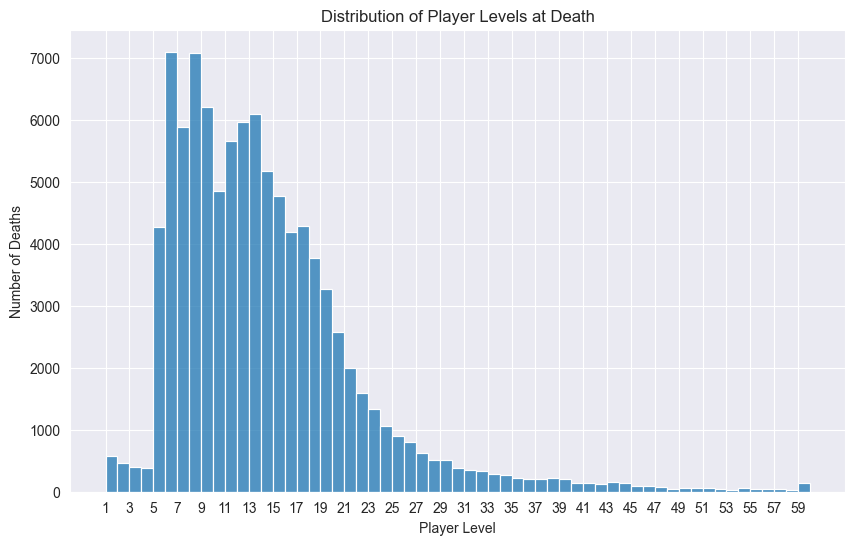

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['level'].dropna(), bins=range(1, 61), kde=False)
plt.title('Distribution of Player Levels at Death')
plt.xlabel('Player Level')
plt.ylabel('Number of Deaths')
plt.xticks(range(1, 61, 2))
plt.show()

### Insights
From the death distribution histogram, we can observe the following:
* Most deaths occur at lower levels, particularly between levels 1 and 20.
* As levels increase, the number of deaths drops significantly, with relatively few deaths in the 30–59 range.
* This suggests that players are more vulnerable at early levels due to limited gear, fewer abilities, lower survivability, and lack of experience.
* The decreasing trend may also reflect the learning curve — players who survive longer tend to become more skilled and cautious.
* Interestingly, there is a **noticeable spike in deaths at level 60**, which is much higher than levels 50–59. This spike likely reflects the challenges of max-level gameplay, such as raids, elite content, world bosses, and increased PvP activity.

## Death Counts Per Class

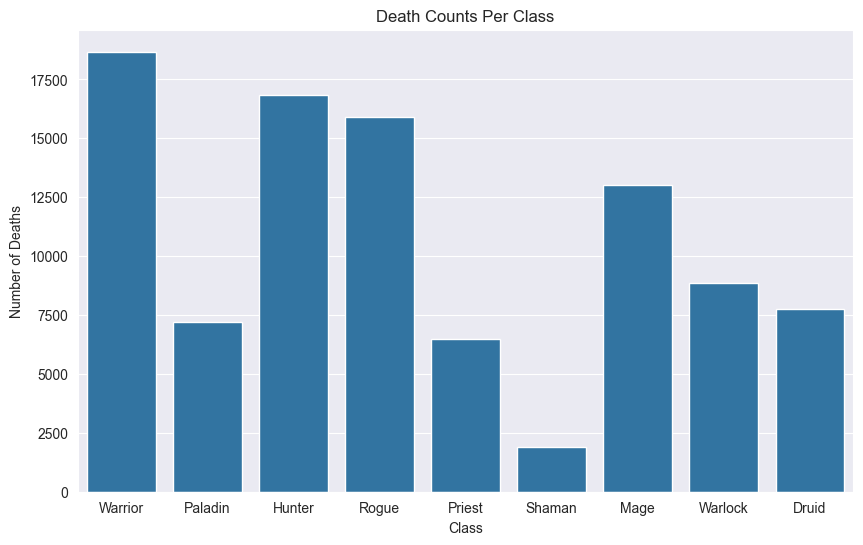

In [9]:
class_deaths = df['class_id'].value_counts().sort_index()
class_deaths_mapped = class_deaths.rename(index=class_id_to_class_name)

plt.figure(figsize=(10, 6))
sns.barplot(x=class_deaths_mapped.index, y=class_deaths_mapped.values)
plt.title('Death Counts Per Class')
plt.xlabel('Class')
plt.ylabel('Number of Deaths')
plt.show()

### Insights
From the death counts per class bar chart, we can observe the following:
* Shamans and Paladins show the lowest total number of deaths. While this might suggest they are the safest classes to play, this conclusion would be premature without accounting for class popularity.
If fewer players choose these classes overall, naturally fewer deaths will be recorded. To make a fair comparison, we would need access to total population counts per class or normalize the deaths per class proportionally.
* Not surprisingly, Warriors have the highest death counts. As a melee class that often serves as a tank, Warriors are frequently in the thick of combat, absorbing damage and facing enemies head-on.
This frontline role inherently increases their risk of death compared to ranged or support classes.

### Proportional Deaths by Class
To better understand class survivability, we can analyze deaths relative to the total number of players in each class.
Using data from the [AOTC Classic Hardcore Leaderboard](https://hc.aotc.gg/population), we obtained the total number of players per class as of November 13, 2025.

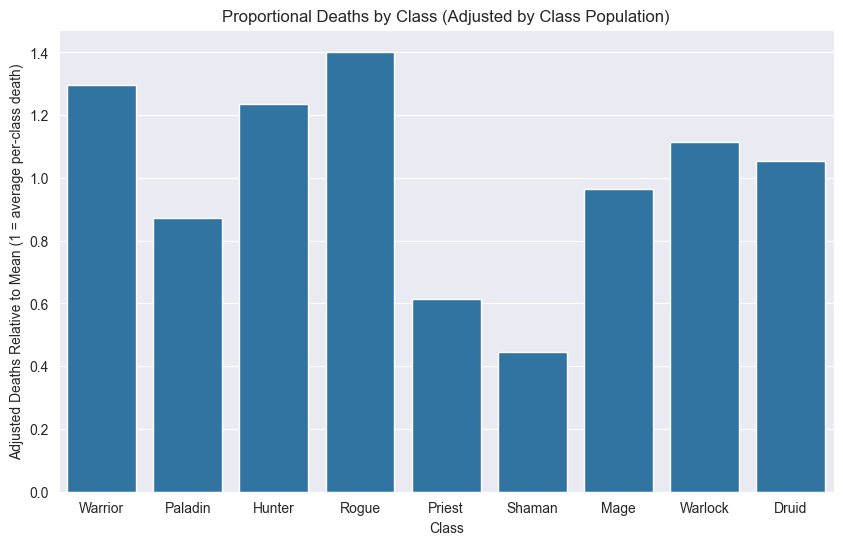

In [10]:
aotc_count_by_class = {
    1: 134_526,
    2: 76_987,
    3: 126_988,
    4: 105_806,
    5: 98_359,
    7: 39_383,
    8: 125_960,
    9: 73_993,
    11: 68_642
}

aotc_total_players = sum(aotc_count_by_class.values())

# Calculate class proportions
class_proportions = {class_id: count / aotc_total_players for class_id, count in aotc_count_by_class.items()}

# Normalize deaths: divide by proportion to get expected deaths if all classes had equal representation
adjusted_deaths = {}
for class_id, death_count in class_deaths.items():
    if class_id in class_proportions:
        # Divide by proportion to "correct" for underrepresentation
        adjusted_deaths[class_id] = death_count / class_proportions[class_id]

# Map class IDs to names
adjusted_deaths_mapped = {class_id_to_class_name[k]: v for k, v in adjusted_deaths.items()}

# Scale for readability (normalize to average = 1000)
average_adjusted = sum(adjusted_deaths_mapped.values()) / len(adjusted_deaths_mapped)
adjusted_deaths_scaled = {k: (v / average_adjusted) for k, v in adjusted_deaths_mapped.items()}

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=list(adjusted_deaths_scaled.keys()), y=list(adjusted_deaths_scaled.values()))
plt.title('Proportional Deaths by Class (Adjusted by Class Population)')
plt.xlabel('Class')
plt.ylabel('Adjusted Deaths Relative to Mean (1 = average per-class death)')
plt.show()

#### Insights
* **Shamans** emerge as the safest class in terms of survivability, followed closely by **Priests**. This aligns with their healing and support abilities, which likely help them survive longer in Hardcore mode.
* Surprisingly, **Rogues** have the highest death rate per player. Their fragile nature and reliance on stealth may lead to high-risk situations, resulting in more frequent deaths when encounters are misjudged.
* Another noteworthy finding is that **Hunters** also show a high death rate, despite being a ranged class with pets that can absorb damage. This may suggest that Hunter players take more risks or face challenges managing their pets effectively in Hardcore mode.


## Death Counts by Map

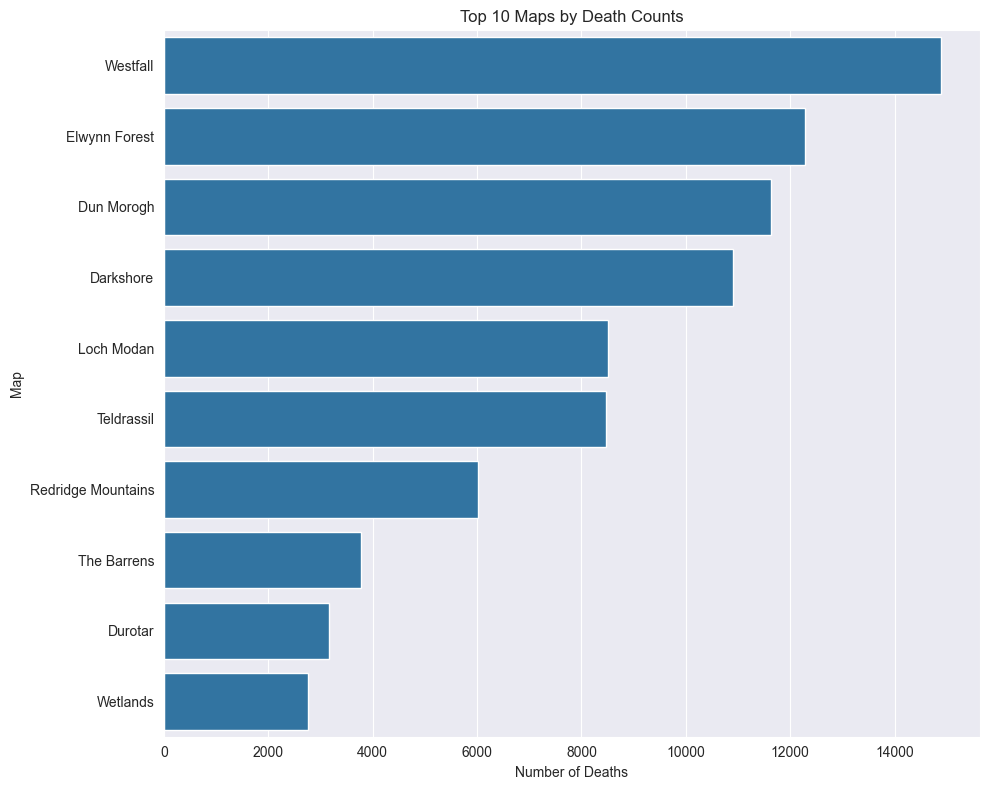

In [11]:
top_maps = df['map_id'].value_counts().head(10)
top_maps_mapped = top_maps.rename(index=map_id_to_map_name)

plt.figure(figsize=(10, 8))
sns.barplot(y=top_maps_mapped.index, x=top_maps_mapped.values)
plt.title('Top 10 Maps by Death Counts')
plt.ylabel('Map')
plt.xlabel('Number of Deaths')
plt.tight_layout()
plt.show()

## Heatmap of Death Counts by Level and Map

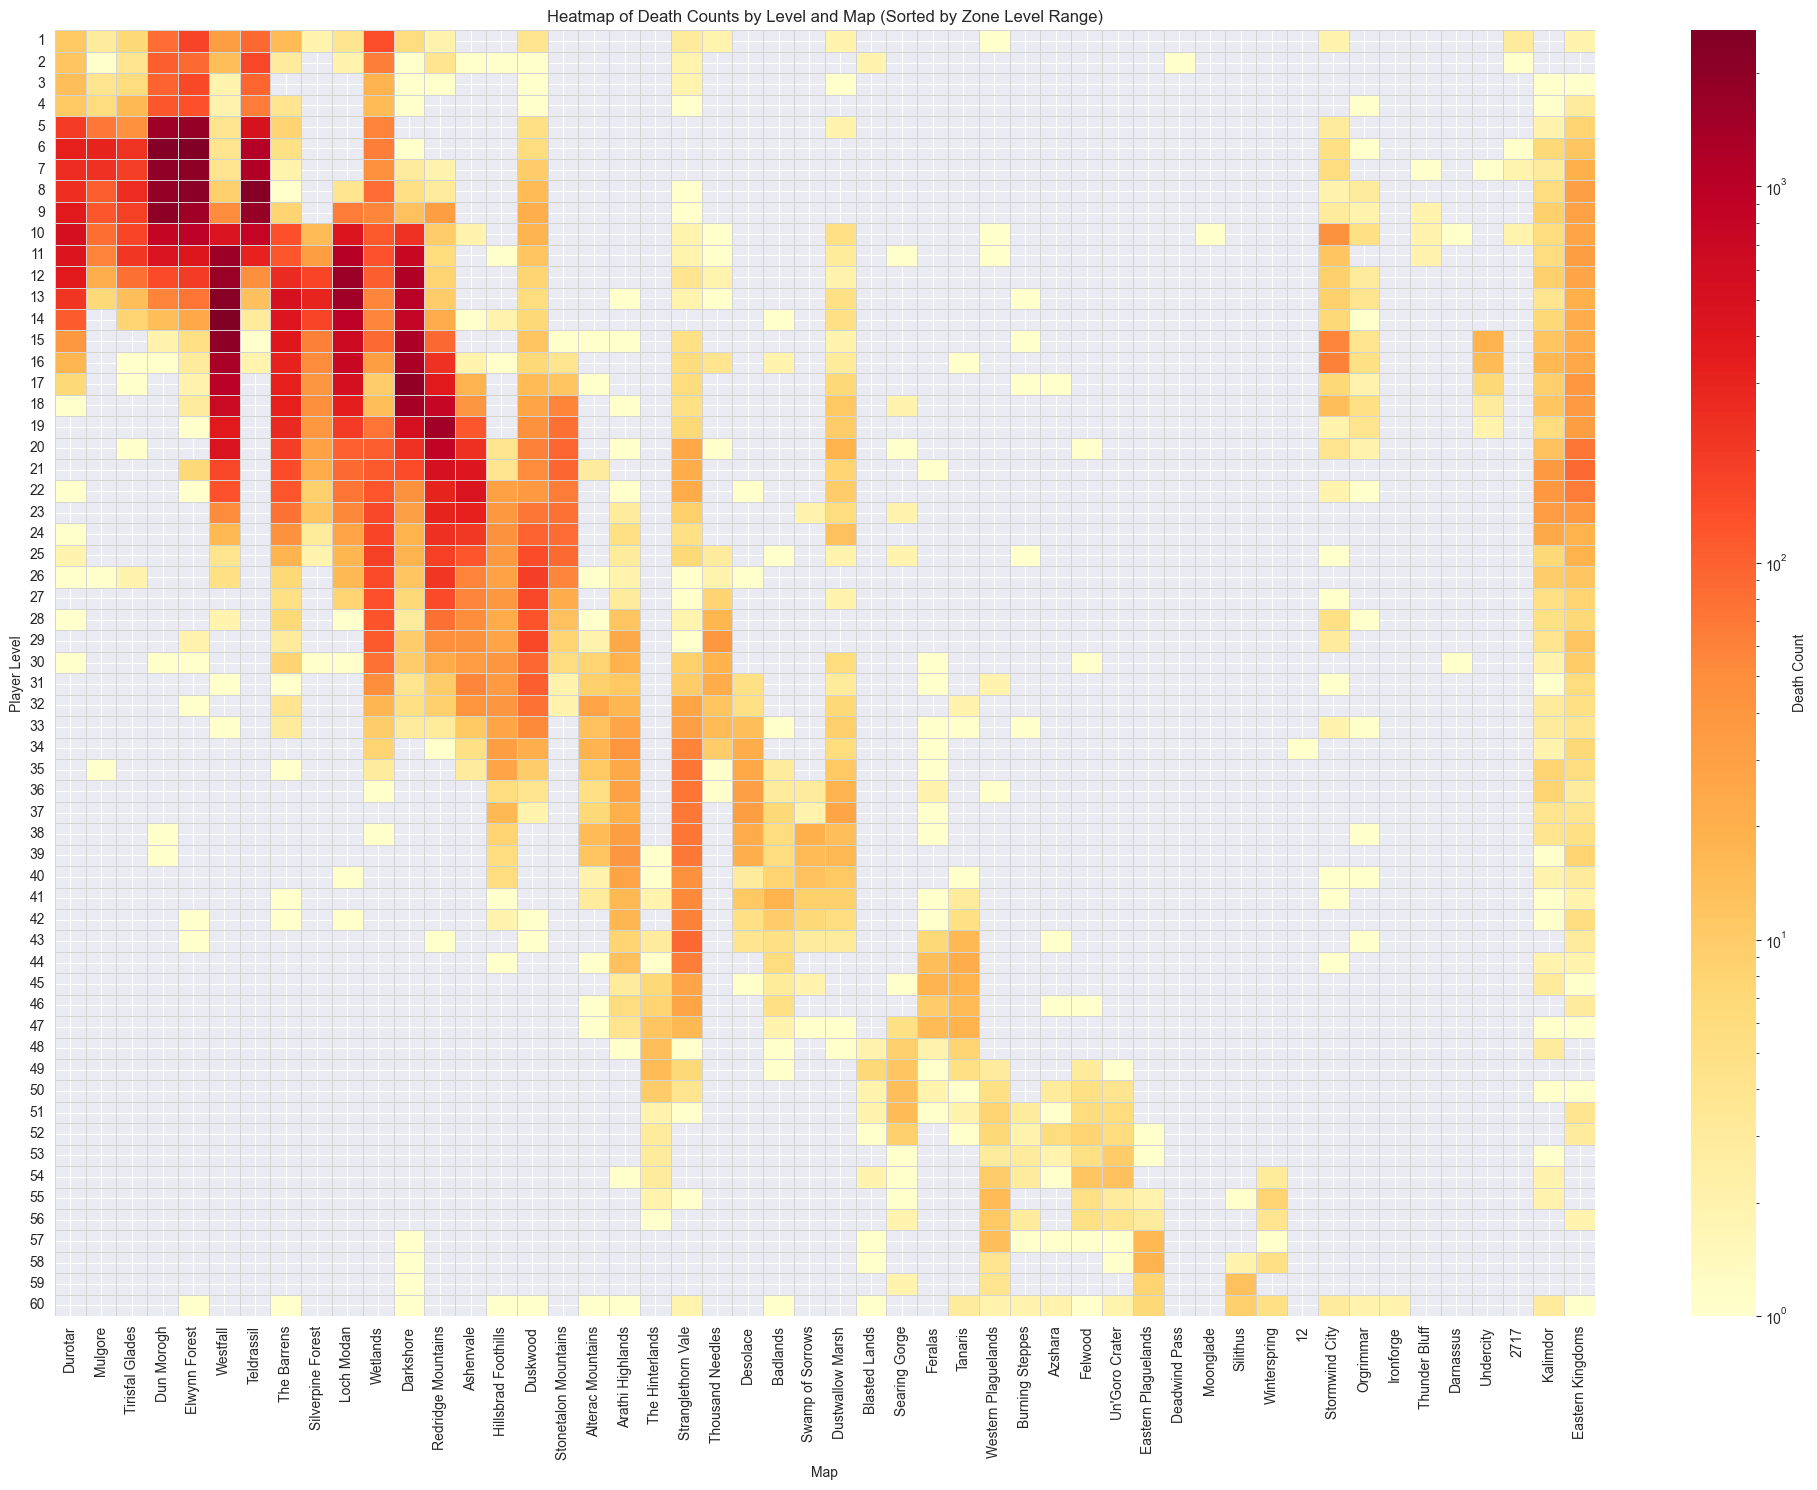

In [12]:
from matplotlib.colors import LogNorm

heatmap_data = df.pivot_table(
    index='level',
    columns='map_id',
    aggfunc='size',
    fill_value=0
)

heatmap_data_mapped = heatmap_data.rename(columns=map_id_to_map_name)

# Create a helper function to get the minimum level for sorting
def get_min_level(map_name):
    # Put continent-wide maps at the end
    if map_name in ['Kalimdor', 'Eastern Kingdoms', 'Azeroth']:
        return 1000  # Sort to the end
    
    # Find the map_id for this map_name
    map_id = next((k for k, v in map_id_to_map_name.items() if v == map_name), None)
    if map_id and map_id in map_id_to_level_range:
        return map_id_to_level_range[map_id][0]  # Return min level
    return 999  # Put other unmapped zones near the end

# Sort columns by minimum level (ascending - lower level zones first)
column_order = sorted(heatmap_data_mapped.columns, key=get_min_level)
heatmap_data_sorted = heatmap_data_mapped[column_order]

plt.figure(figsize=(20, 15))
ax = sns.heatmap(
    heatmap_data_sorted, 
    cmap='YlOrRd',
    norm=LogNorm(),
    cbar_kws={'label': 'Death Count'},
    linewidths=0.5,
    linecolor='lightgray'
)

plt.title("Heatmap of Death Counts by Level and Map (Sorted by Zone Level Range)")
plt.xlabel("Map")
plt.ylabel("Player Level")
plt.xticks(rotation=90, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Insights
* The heatmap shows that certain maps experience higher death counts at specific level ranges, which aligns with the intended difficulty design of zones for different player levels.
* Starting zones like Dun Morogh and Elwynn Forest exhibit elevated death counts at lower levels (1–20), reflecting the high population of new players and their limited experience.
* While the heatmap shows a diagonal pattern—high death counts in low-level zones and progressively fewer deaths in higher-level zones—this trend should not be interpreted solely as players becoming more skilled or better equipped at higher levels. A major contributing factor is population density: significantly more players are present in early-level zones, and far fewer reach the mid- to high-level zones.
Because the dataset reflects absolute death counts rather than death rates per active player, lower-level zones naturally accumulate many more deaths simply due to having more players.

### Notes
There are some anomalies in the data, such as deaths recorded in maps that do not align with expected level ranges. For example, `map_id = 12` and `map_id = 2717` do not correspond to
any known zones in WoW Classic and likely represent data entry errors or misclassifications.

We can try examining which rows have these map IDs:

In [13]:
# Find all rows that have map_id = 12 (Because it is wrong)
wrong_map_rows_12 = df[df['map_id'] == 12]
print(wrong_map_rows_12)

                                    map_id         map_pos  class_id  area_id  \
JösephStarting Zone Enjoyer3415727      12  [445.6, 306.4]         4       12   

                                    source_id  level  instance_id  
JösephStarting Zone Enjoyer3415727      15727     34         <NA>  


We can see that there is only one row with `map_id = 12`. Let's examine which NPC caused the death in this case. The NPC ID is stored in the `source_id = 15727`. We can look it up
in a database like [Wowhead](https://classic.wowhead.com/) to find out more about it.

Base of the Wowhead the NPC with ID `15727` is  [C'Thun](https://classic.wowhead.com/npc=15727/cthun), the final boss of the raid instance `Ahn'Qiraj`.
Which is definitely not a zone where level 34 player could possibly die. This suggests that the whole row is likely a data entry error or misclassification.

In [14]:
wrong_map_rows_2717 = df[df['map_id'] == 2717]
print(wrong_map_rows_2717)
print(f"Number of rows with map_id = 2717: {len(wrong_map_rows_2717)}")

                                     map_id  \
JøanaPexing Academy HC1011502          2717   
AsjkldjklHardcore Raiders111502        2717   
TinfoilheadHardcore and Chill115990    2717   
LvlagainImmortalNoobs611502            2717   
JÃ¸anaPexing Academy HC1011502         2717   
JøanaPexing Academy HC711502           2717   
MoistmeatHARDCORE ZONERS111502         2717   
MoistmeatHARDCORE ZONERS211502         2717   
MoistmeatHARDCORE ZONERS711502         2717   

                                                                      map_pos  \
JøanaPexing Academy HC1011502        [133.70000000000002, 133.70000000000002]   
AsjkldjklHardcore Raiders111502      [133.70000000000002, 133.70000000000002]   
TinfoilheadHardcore and Chill115990                              [45.1, 45.1]   
LvlagainImmortalNoobs611502          [133.70000000000002, 133.70000000000002]   
JÃ¸anaPexing Academy HC1011502       [133.70000000000002, 133.70000000000002]   
JøanaPexing Academy HC711502         [133.7

When examining the rows with `map_id = 2717` we find total of 9 rows. The `source_id`s in these rows are: `11502` and `15990`, which correspond to the following NPCs:
* [Ragnaros](https://classic.wowhead.com/npc=11502)
* [Kel'Thuzad](https://classic.wowhead.com/npc=15990)

Both of these NPCs are raid bosses from `Molten Core` and `Naxxramas` respectively, which again do not align with the level ranges of the players who died in these instances.
This further supports the conclusion that these rows are likely data entry errors or misclassifications.

#### Observation
We also can see that the names of the players contain the ID of the NPC that killed them. This suggests that the data might have been generated or logged in manually.

## Level at Death By Class

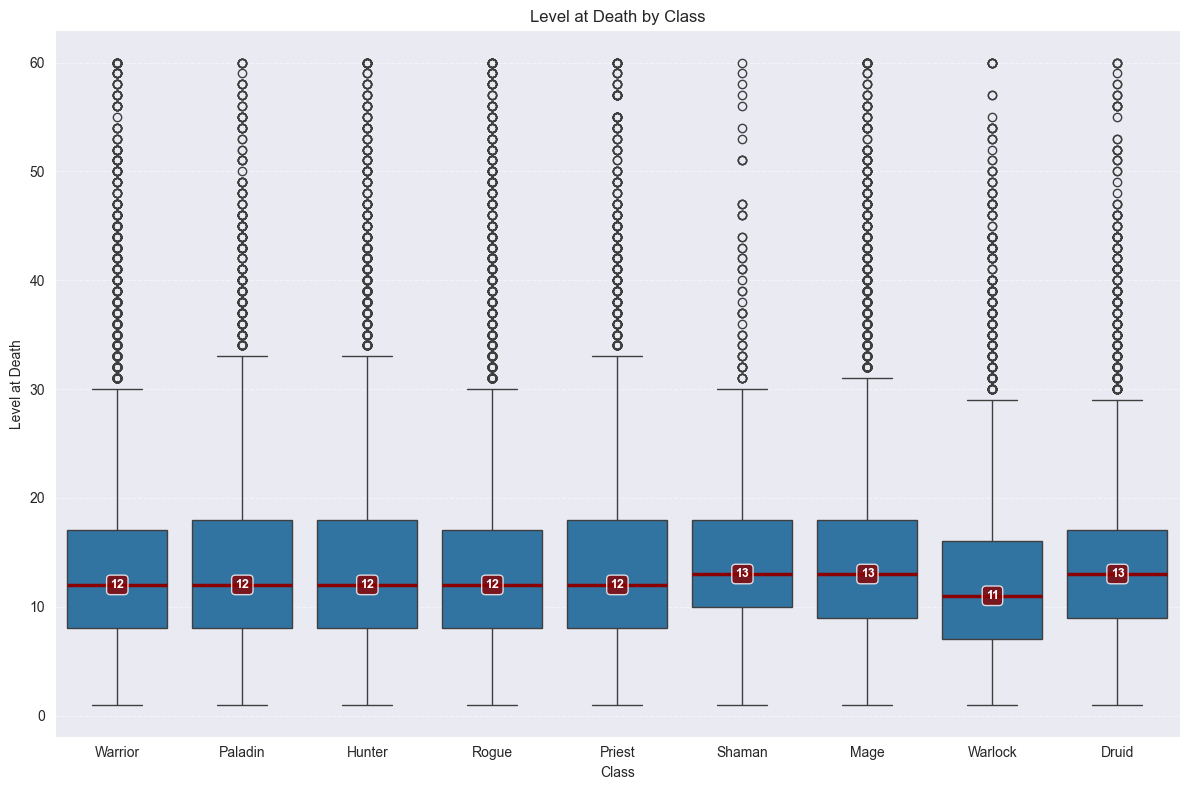

In [15]:
plt.figure(figsize=(12, 8))
ax = sns.boxplot(x='class_id', y='level', data=df, order=sorted(class_id_to_class_name.keys()),
                 medianprops=dict(color='darkred', linewidth=2.5))
plt.xticks(ticks=range(len(class_id_to_class_name)), labels=[class_id_to_class_name[i] for i in sorted(class_id_to_class_name.keys())])

# Add gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Annotate medians
medians = df.groupby('class_id')['level'].median()
for i, class_id in enumerate(sorted(class_id_to_class_name.keys())):
    median_val = medians[class_id]
    ax.text(i, median_val, f'{median_val:.0f}', 
            ha='center', va='center', fontweight='bold', 
            fontsize=9, color='white', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='darkred', alpha=0.8))

plt.title('Level at Death by Class')
plt.xlabel('Class')
plt.ylabel('Level at Death')
plt.tight_layout()
plt.show()

### Insights
* These results are pretty surprising. The median death level for all classes hovers around level 12. This suggests that most player deaths occur early in the leveling process, likely due to inexperience and lack of gear.
* What is particularly interesting is that pretty safe class like Warlock has the lowest median death level at 11. This is most likely cause by his class quest at level 10
which requires players to face a challenging encounter that can lead to early deaths.

## Class Deaths By Map Location

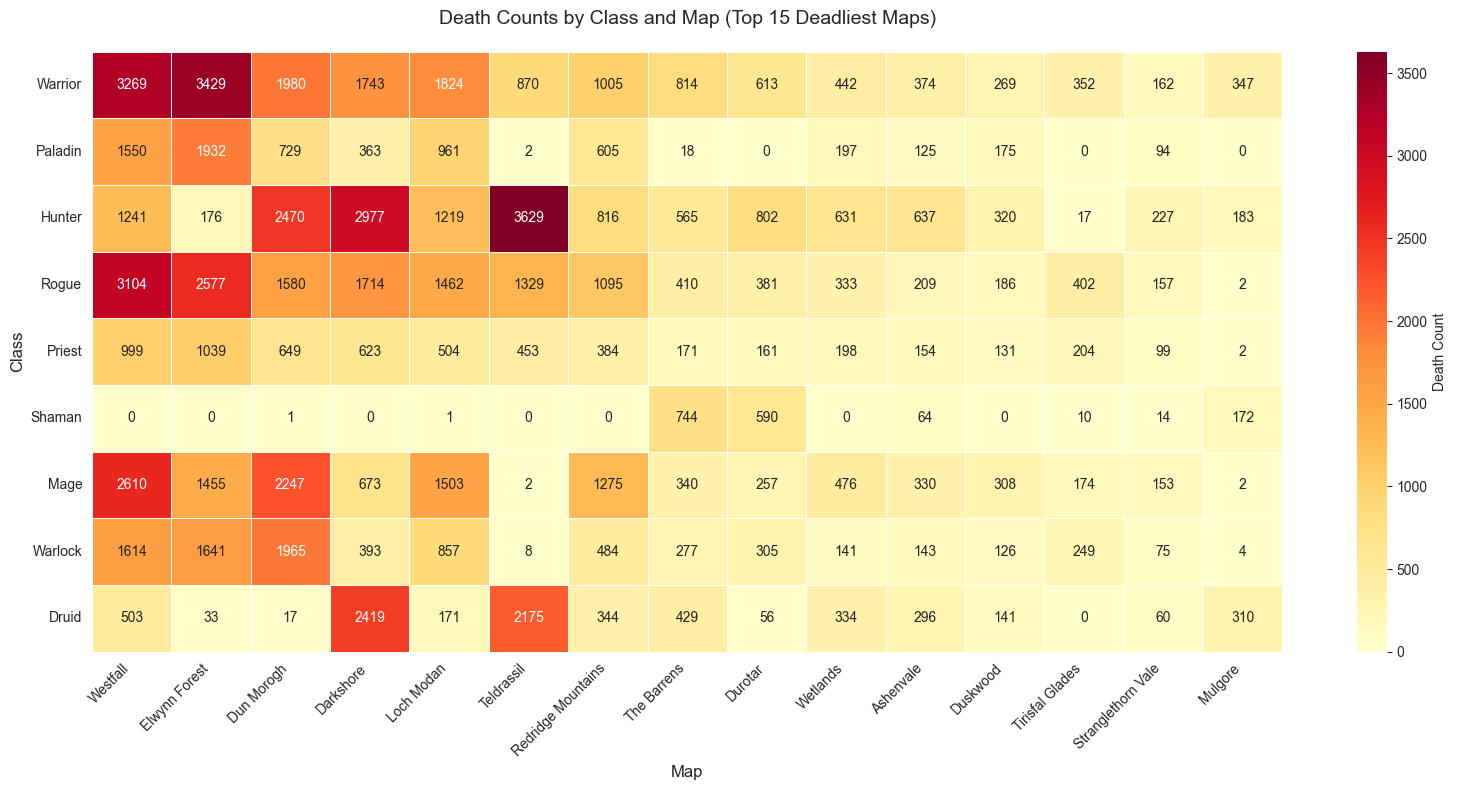

In [16]:
# Create a pivot table showing deaths by class and map
class_map_deaths = df.pivot_table(
    index='class_id',
    columns='map_id',
    aggfunc='size',
    fill_value=0
)

# Map class IDs to class names
class_map_deaths_named = class_map_deaths.rename(index=class_id_to_class_name)

# Map map IDs to map names
class_map_deaths_named = class_map_deaths_named.rename(columns=map_id_to_map_name)

# Filter to show only top 15 deadliest maps for better readability
top_15_maps = df['map_id'].value_counts().head(15).index
top_15_map_names = [map_id_to_map_name.get(map_id, f'Map {map_id}') for map_id in top_15_maps]
class_map_filtered = class_map_deaths_named[top_15_map_names]

# Create heatmap
plt.figure(figsize=(16, 8))
ax = sns.heatmap(
    class_map_filtered,
    cmap='YlOrRd',
    annot=True,
    fmt='g',
    cbar_kws={'label': 'Death Count'},
    linewidths=0.5,
    linecolor='white'
)

plt.title('Death Counts by Class and Map (Top 15 Deadliest Maps)', fontsize=14, pad=20)
plt.xlabel('Map', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Insights
* In Elwynn Forest, Rogues have fewer deaths than Warriors, and the gap between the two classes is larger here than in Westfall.
This suggests that Rogues are particularly effective at surviving in Elwynn Forest, while in Westfall the survival advantage of Rogues over Warriors is smaller.
* In Durotar, Warriors and Shamans have similar death counts, whereas in Mulgore, Shamans die about half as often as Warriors.
This may indicate that Shamans are either better suited for surviving in Mulgore, or that player race/class choices (Orc/Troll Shamans in Durotar vs. Tauren Shamans in Mulgore) influence survival outcomes.

## Top Killer NPCs

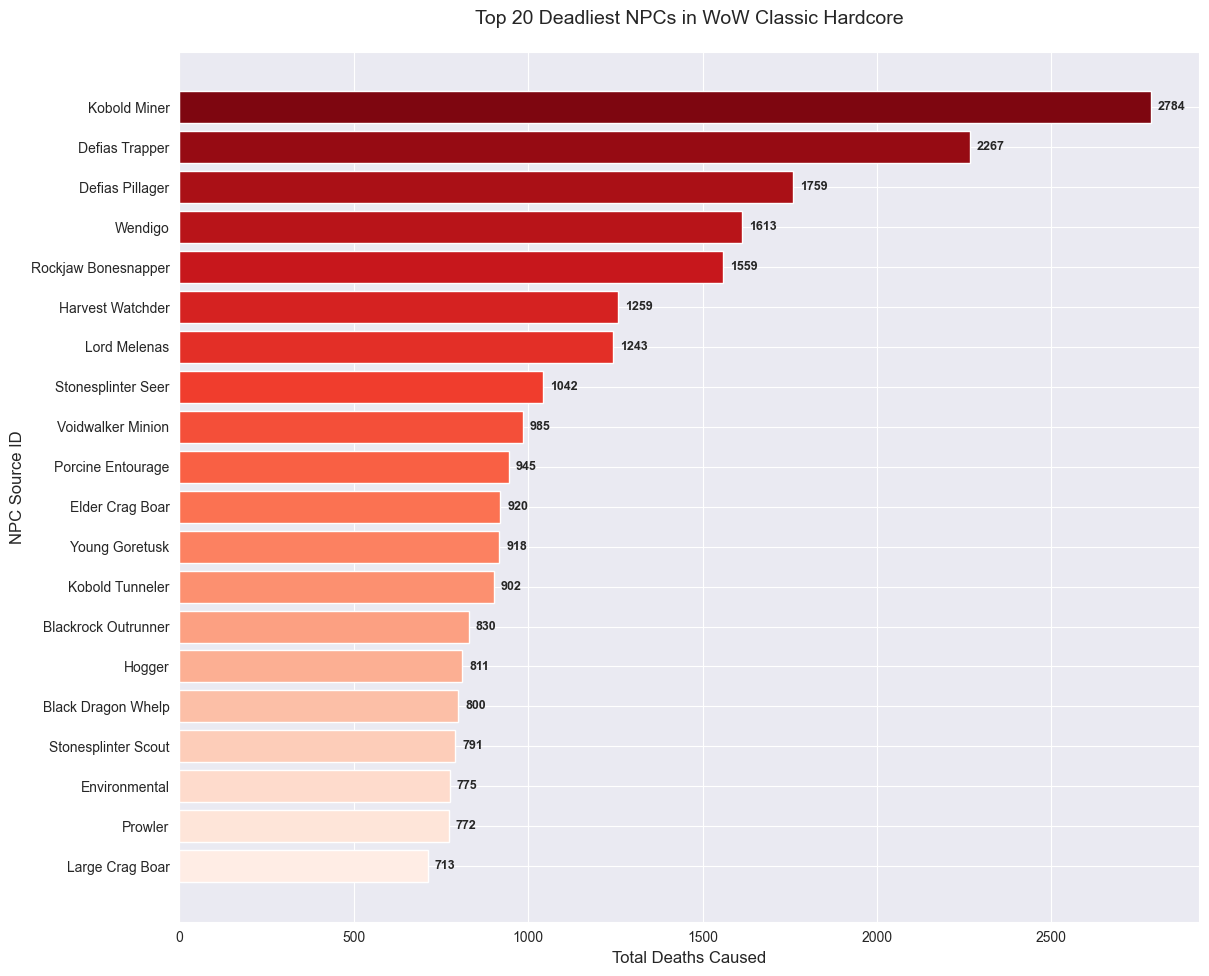

In [17]:
# Get top 20 killer NPCs
top_killers = df['source_id'].value_counts().head(20)

# Create a simple color palette
colors = sns.color_palette('Reds_r', n_colors=len(top_killers))

top_killers_mapped = top_killers.rename(index=npc_id_to_npc_name)

plt.figure(figsize=(12, 10))
ax = plt.barh(range(len(top_killers_mapped)), top_killers_mapped.values, color=colors)

# Set y-axis labels
plt.yticks(range(len(top_killers_mapped)), top_killers_mapped.index)

# Add value labels on the bars
for i, v in enumerate(top_killers_mapped.values):
    plt.text(v + 20, i, str(v), va='center', fontweight='bold', fontsize=9)

plt.title('Top 20 Deadliest NPCs in WoW Classic Hardcore', fontsize=14, pad=20)
plt.xlabel('Total Deaths Caused', fontsize=12)
plt.ylabel('NPC Source ID', fontsize=12)
plt.gca().invert_yaxis()  # Invert to have highest at top
plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.08)
plt.show()

### Insights
* The visualization shows the most deadly NPCs in WoW Classic Hardcore by their source IDs.
* Since NPC names are not included in the dataset, the source IDs can be looked up on databases like [Wowhead](https://classic.wowhead.com/) to identify specific enemies.
* The distribution shows that certain NPCs are significantly more dangerous than others, likely representing:
  - **Common leveling enemies** that players encounter frequently
  - **Elite mobs** or challenging enemies in popular zones
  - **Ganking-related deaths** in contested PvP zones
* The top killer NPCs account for a disproportionate number of total deaths, suggesting that specific encounters pose the greatest risk to Hardcore players.

## Top Killers by Level Bracket

In [18]:
# Create level brackets
df['level_bracket'] = pd.cut(
    df['level'], 
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=['1-10', '11-20', '21-30', '31-40', '41-50', '51-60']
)

# Get top 5 killers for each level bracket
level_brackets = ['1-10', '11-20', '21-30', '31-40', '41-50', '51-60']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, bracket in enumerate(level_brackets):
    bracket_data = df[df['level_bracket'] == bracket]
    top_killers_bracket = bracket_data['source_id'].value_counts().head(10)
    
    ax = axes[idx]
    if len(top_killers_bracket) > 0:
        sns.barplot(x=top_killers_bracket.values, y=top_killers_bracket.index, 
                   palette='Reds_r', ax=ax)
        
        # Add value labels
        for i, v in enumerate(top_killers_bracket.values):
            ax.text(v + (v * 0.02), i, str(v), va='center', fontsize=8, fontweight='bold')
        
        ax.set_title(f'Level {bracket}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Deaths', fontsize=10)
        ax.set_ylabel('NPC Source ID', fontsize=10)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Level {bracket}', fontsize=12, fontweight='bold')

plt.suptitle('Top 10 Deadliest NPCs by Level Bracket', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nTop Killer NPCs by Level Bracket:")
print("=" * 70)
for bracket in level_brackets:
    bracket_data = df[df['level_bracket'] == bracket]
    top_3 = bracket_data['source_id'].value_counts().head(3)
    print(f"\nLevel {bracket}:")
    for rank, (source_id, count) in enumerate(top_3.items(), 1):
        print(f"  {rank}. Source ID {source_id}: {count} deaths")

/var/folders/x8/nk8375rj1j1_z078xskcnz4c0000gn/T/ipykernel_13748/3856436026.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_killers_bracket.values, y=top_killers_bracket.index,
/var/folders/x8/nk8375rj1j1_z078xskcnz4c0000gn/T/ipykernel_13748/3856436026.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_killers_bracket.values, y=top_killers_bracket.index,
/var/folders/x8/nk8375rj1j1_z078xskcnz4c0000gn/T/ipykernel_13748/3856436026.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_killers_bracket.values, y=top_killer


Top Killer NPCs by Level Bracket:

Level 1-10:
  1. Source ID 40: 2768 deaths
  2. Source ID 1135: 1609 deaths
  3. Source ID 1117: 1252 deaths

Level 11-20:
  1. Source ID 504: 2214 deaths
  2. Source ID 589: 1753 deaths
  3. Source ID 114: 1191 deaths

Level 21-30:
  1. Source ID 431: 221 deaths
  2. Source ID 485: 192 deaths
  3. Source ID 3917: 181 deaths

Level 31-40:
  1. Source ID 2405: 113 deaths
  2. Source ID 1871: 91 deaths
  3. Source ID -1: 88 deaths

Level 41-50:
  1. Source ID 1565: 37 deaths
  2. Source ID 6388: 34 deaths
  3. Source ID -1: 31 deaths

Level 51-60:
  1. Source ID -1: 20 deaths
  2. Source ID 9862: 13 deaths
  3. Source ID 10577: 13 deaths


### Insights
* The level bracket analysis reveals how the most dangerous NPCs change as players progress through the game.
* **Early levels (1-10)**: The deadliest NPCs in this bracket likely include common enemies in starting zones that catch inexperienced players off-guard. The high death counts reflect both the large player population at these levels and the learning curve.
* **Mid levels (11-30)**: These brackets show a transition period where players encounter more challenging enemies. The distribution of deaths becomes more spread out across different NPCs, suggesting players face more varied threats.
* **High levels (31-60)**: The deadliest NPCs in higher brackets typically represent:
  - Elite mobs in contested zones
  - Dungeon enemies where players attempt risky group content
  - PvP-related deaths in high-level contested areas
* **Death count decreases**: Notice how the total death counts per NPC generally decrease in higher level brackets, reflecting the smaller player population that reaches these levels.
* **Consistent threats**: Some NPCs may appear across multiple level brackets if they exist in zones with wide level ranges (e.g., Stranglethorn Vale spans levels 30-45).